In [ ]:
!pip install -q kagglehub[pandas-datasets]

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "ankushnarwade/indian-climate-dataset-20242025"
)

print("Dataset downloaded to:")
print(path)

import os

print("\nFiles in dataset:")
for file in os.listdir(path):
    print(file)

Using Colab cache for faster access to the 'indian-climate-dataset-20242025' dataset.
Dataset downloaded to:
/kaggle/input/indian-climate-dataset-20242025

Files in dataset:
Indian_Climate_Dataset_2024_2025.csv


In [ ]:
import pandas as pd
import os

file_path = os.path.join(path, "Indian_Climate_Dataset_2024_2025.csv")

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (7310, 13)


,Date,City,State,Temperature_Max (°C),Temperature_Min (°C),Temperature_Avg (°C),Humidity (%),Rainfall (mm),Wind_Speed (km/h),AQI,AQI_Category,Pressure (hPa),Cloud_Cover (%)
0,2024-01-01,Mumbai,Maharashtra,32.5,18.0,25.2,77.6,0.0,3.3,259,Poor,1020.3,62.1
1,2024-01-01,Delhi,Delhi,25.4,10.7,18.1,84.1,0.0,9.0,130,Moderate,1008.4,46.0
2,2024-01-01,Bengaluru,Karnataka,37.2,30.8,34.0,49.0,3.7,6.6,54,Satisfactory,1008.0,61.3
3,2024-01-01,Chennai,Tamil Nadu,37.2,30.4,33.8,34.2,9.5,9.0,176,Moderate,993.4,70.0
4,2024-01-01,Kolkata,West Bengal,27.4,17.5,22.5,32.2,9.1,9.2,97,Satisfactory,1008.2,56.9


In [ ]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Columns:
['Date', 'City', 'State', 'Temperature_Max (°C)', 'Temperature_Min (°C)', 'Temperature_Avg (°C)', 'Humidity (%)', 'Rainfall (mm)', 'Wind_Speed (km/h)', 'AQI', 'AQI_Category', 'Pressure (hPa)', 'Cloud_Cover (%)']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7310 entries, 0 to 7309
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  7310 non-null   object 
 1   City                  7310 non-null   object 
 2   State                 7310 non-null   object 
 3   Temperature_Max (°C)  7310 non-null   float64
 4   Temperature_Min (°C)  7310 non-null   float64
 5   Temperature_Avg (°C)  7310 non-null   float64
 6   Humidity (%)          7310 non-null   float64
 7   Rainfall (mm)         7310 non-null   float64
 8   Wind_Speed (km/h)     7310 non-null   float64
 9   AQI                   7310 non-null   int64  
 10  AQI_Category          7310 non-nu

In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()

# Remove rows containing missing values
df = df.dropna()

print("Dataset shape after cleaning:", df.shape)
print("Missing values:")
print(df.isnull().sum())

Dataset shape after cleaning: (7310, 13)
Missing values:
Date                    0
City                    0
State                   0
Temperature_Max (°C)    0
Temperature_Min (°C)    0
Temperature_Avg (°C)    0
Humidity (%)            0
Rainfall (mm)           0
Wind_Speed (km/h)       0
AQI                     0
AQI_Category            0
Pressure (hPa)          0
Cloud_Cover (%)         0
dtype: int64


In [ ]:
print(df.columns.tolist())

['Date', 'City', 'State', 'Temperature_Max (°C)', 'Temperature_Min (°C)', 'Temperature_Avg (°C)', 'Humidity (%)', 'Rainfall (mm)', 'Wind_Speed (km/h)', 'AQI', 'AQI_Category', 'Pressure (hPa)', 'Cloud_Cover (%)']


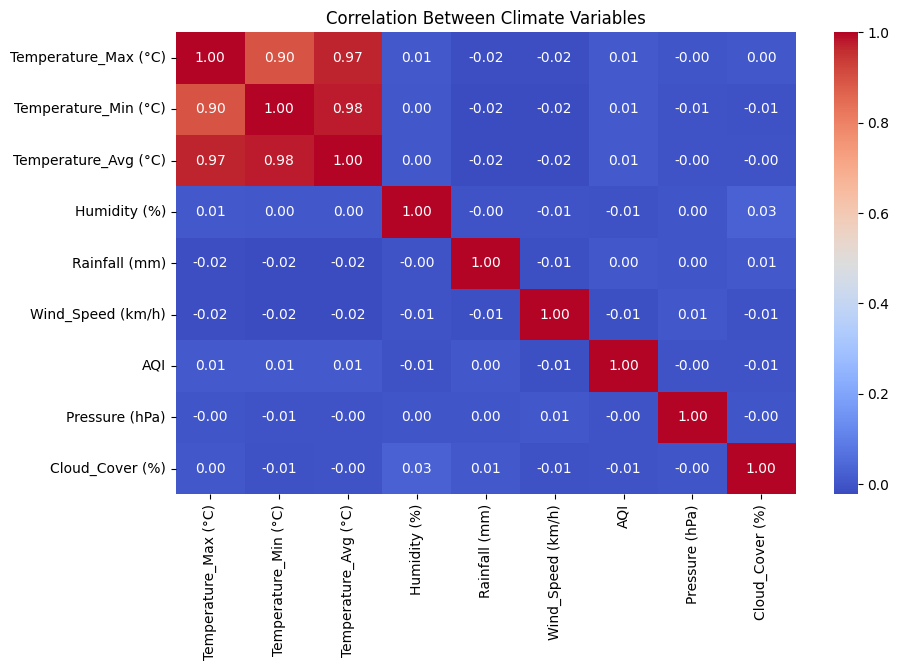

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Climate Variables")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Select only the numerical columns for scaling
numerical_cols = [
    'Temperature_Max (°C)', 'Temperature_Min (°C)', 'Temperature_Avg (°C)',
    'Humidity (%)', 'Rainfall (mm)', 'Wind_Speed (km/h)', 'AQI',
    'Pressure (hPa)', 'Cloud_Cover (%)'
]
X = df[numerical_cols]

X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (7310, 9)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original number of features:", X_scaled.shape[1])
print("PCA dimensions:", X_pca.shape[1])

Original number of features: 9
PCA dimensions: 2


In [ ]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Explained variance ratio:
[0.32183772 0.11500583]
Total explained variance: 0.43684354869950826


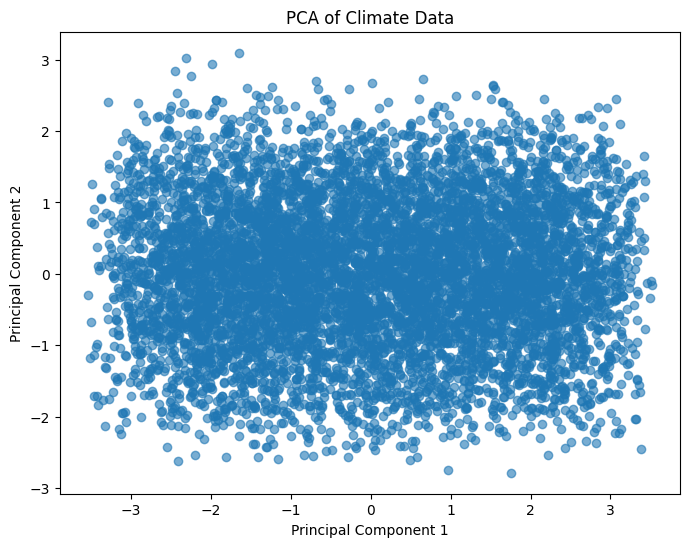

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Climate Data")

plt.show()

In [ ]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_pca)

    inertia.append(kmeans.inertia_)

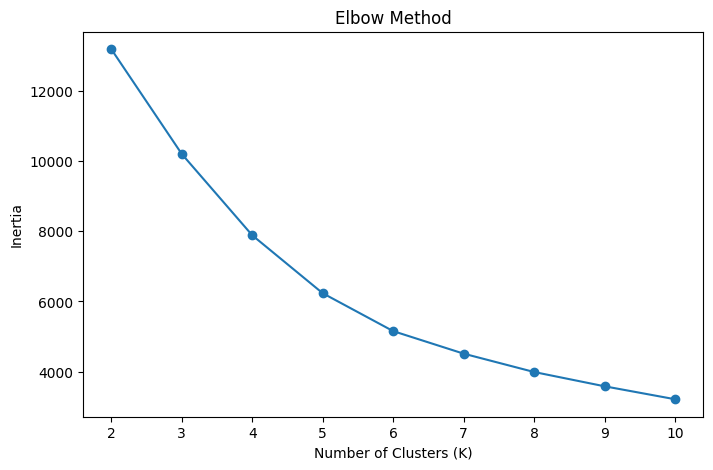

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

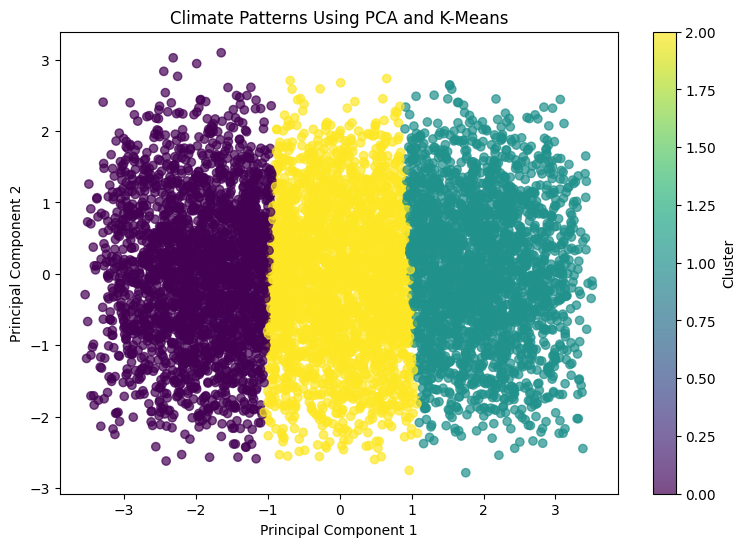

In [ ]:
from sklearn.cluster import KMeans

# Choose the optimal number of clusters based on the elbow method
optimal_clusters = 3  # Based on the Elbow Method plot

kmeans = KMeans(
    n_clusters=optimal_clusters,
    random_state=42,
    n_init=10
)

kmeans.fit(X_pca)

clusters = kmeans.labels_

plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Climate Patterns Using PCA and K-Means")

plt.colorbar(label="Cluster")

plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_pca,
    clusters
)

print("Silhouette Score:", round(score, 4))

Silhouette Score: 0.3364


In [ ]:
for k in range(2, 7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_pca)

    score = silhouette_score(
        X_pca,
        labels
    )

    print(
        f"K = {k} → Silhouette Score = {score:.4f}"
    )

K = 2 → Silhouette Score = 0.4532
K = 3 → Silhouette Score = 0.3364
K = 4 → Silhouette Score = 0.3549
K = 5 → Silhouette Score = 0.3417
K = 6 → Silhouette Score = 0.3339


In [ ]:
df['Cluster'] = clusters
features = numerical_cols

cluster_analysis = df.groupby("Cluster")[features].mean()

display(cluster_analysis)

,Temperature_Max (°C),Temperature_Min (°C),Temperature_Avg (°C),Humidity (%),Rainfall (mm),Wind_Speed (km/h),AQI,Pressure (hPa),Cloud_Cover (%)
Cluster,,,,,,,,,
0,28.432352,17.812816,23.123683,62.889963,8.848445,13.653049,191.436748,1007.437453,52.880050
1,41.553078,32.183319,36.869509,63.238727,7.794384,13.167263,194.529118,1007.284692,53.332737
2,34.892305,25.042645,29.967816,61.861162,8.055912,13.739399,195.262525,1007.353547,51.711423


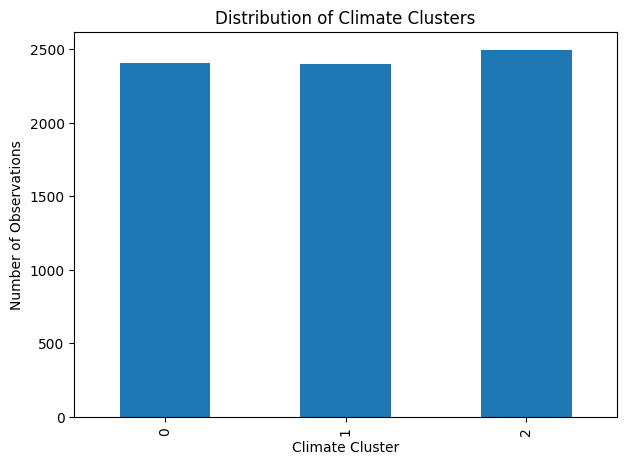

In [ ]:
plt.figure(figsize=(7, 5))

df["Cluster"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Climate Cluster")
plt.ylabel("Number of Observations")
plt.title("Distribution of Climate Clusters")

plt.show()

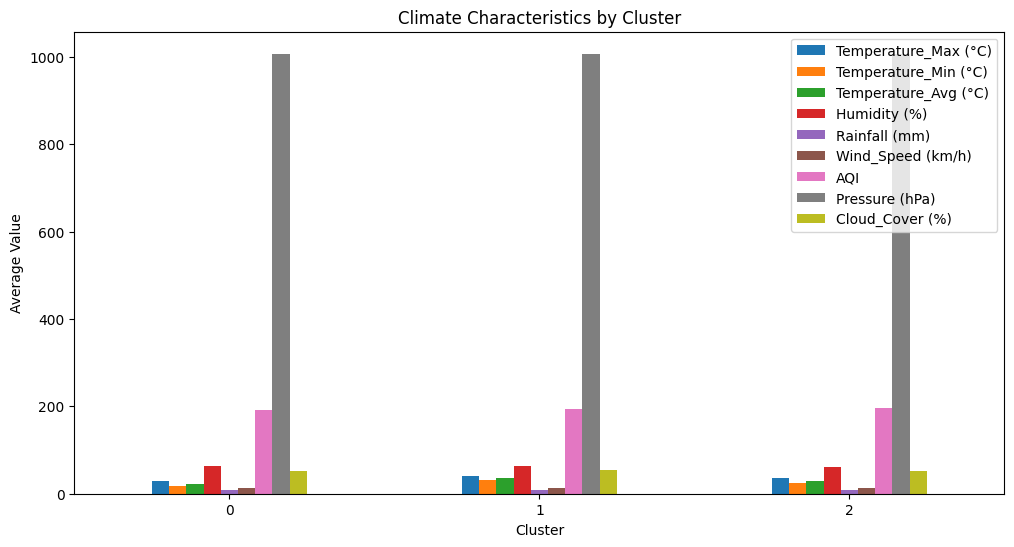

In [ ]:
cluster_analysis.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.title("Climate Characteristics by Cluster")

plt.xticks(rotation=0)

plt.show()

In [ ]:
cluster_names = {
    0: "Hot and Dry",
    1: "Cool and Wet",
    2: "Moderate Climate"
}

df["Climate_Pattern"] = df["Cluster"].map(cluster_names)

display(
    df[["Cluster", "Climate_Pattern"]].head()
)

,Cluster,Climate_Pattern
0,0,Hot and Dry
1,0,Hot and Dry
2,1,Cool and Wet
3,1,Cool and Wet
4,0,Hot and Dry


In [ ]:
df.to_csv(
    "climate_pattern_analysis_results.csv",
    index=False
)

print("Final results saved successfully!")

Final results saved successfully!


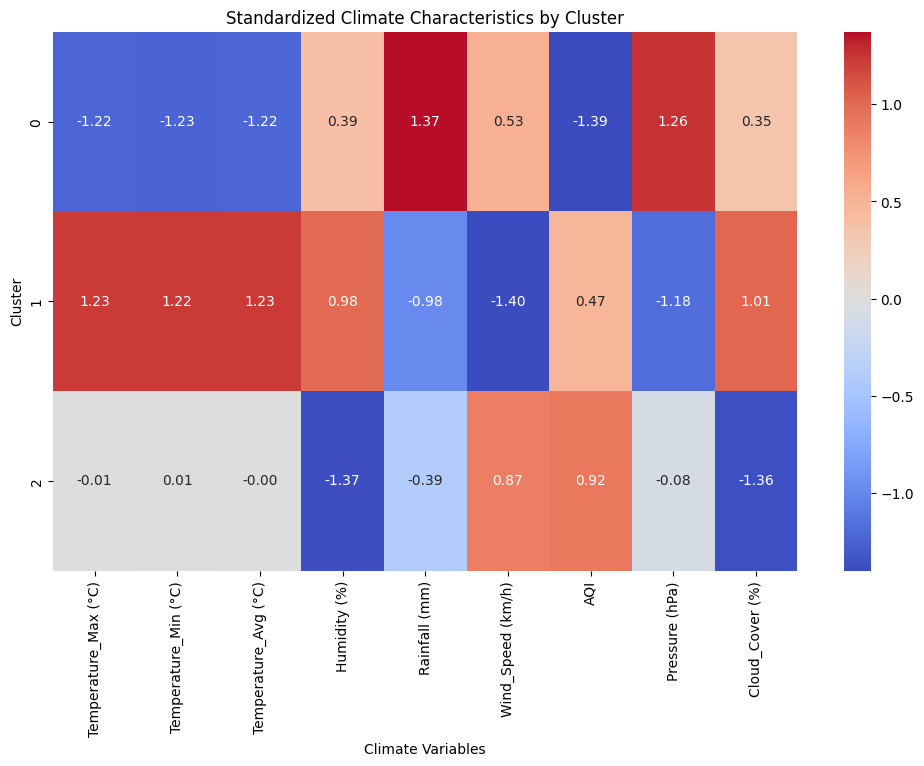

In [ ]:
# Standardize cluster averages for visualization

cluster_mean = df.groupby("Cluster")[features].mean()

cluster_mean_scaled = pd.DataFrame(
    StandardScaler().fit_transform(cluster_mean),
    index=cluster_mean.index,
    columns=cluster_mean.columns
)

plt.figure(figsize=(12, 7))

sns.heatmap(
    cluster_mean_scaled,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Standardized Climate Characteristics by Cluster")
plt.xlabel("Climate Variables")
plt.ylabel("Cluster")

plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

print("Silhouette Scores:")

for k in range(2, 8):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_pca)

    score = silhouette_score(X_pca, labels)

    print(f"K = {k} → {score:.4f}")

Silhouette Scores:
K = 2 → 0.4532
K = 3 → 0.3364
K = 4 → 0.3549
K = 5 → 0.3417
K = 6 → 0.3339
K = 7 → 0.3328


Number of records: 7310
Number of features: 8


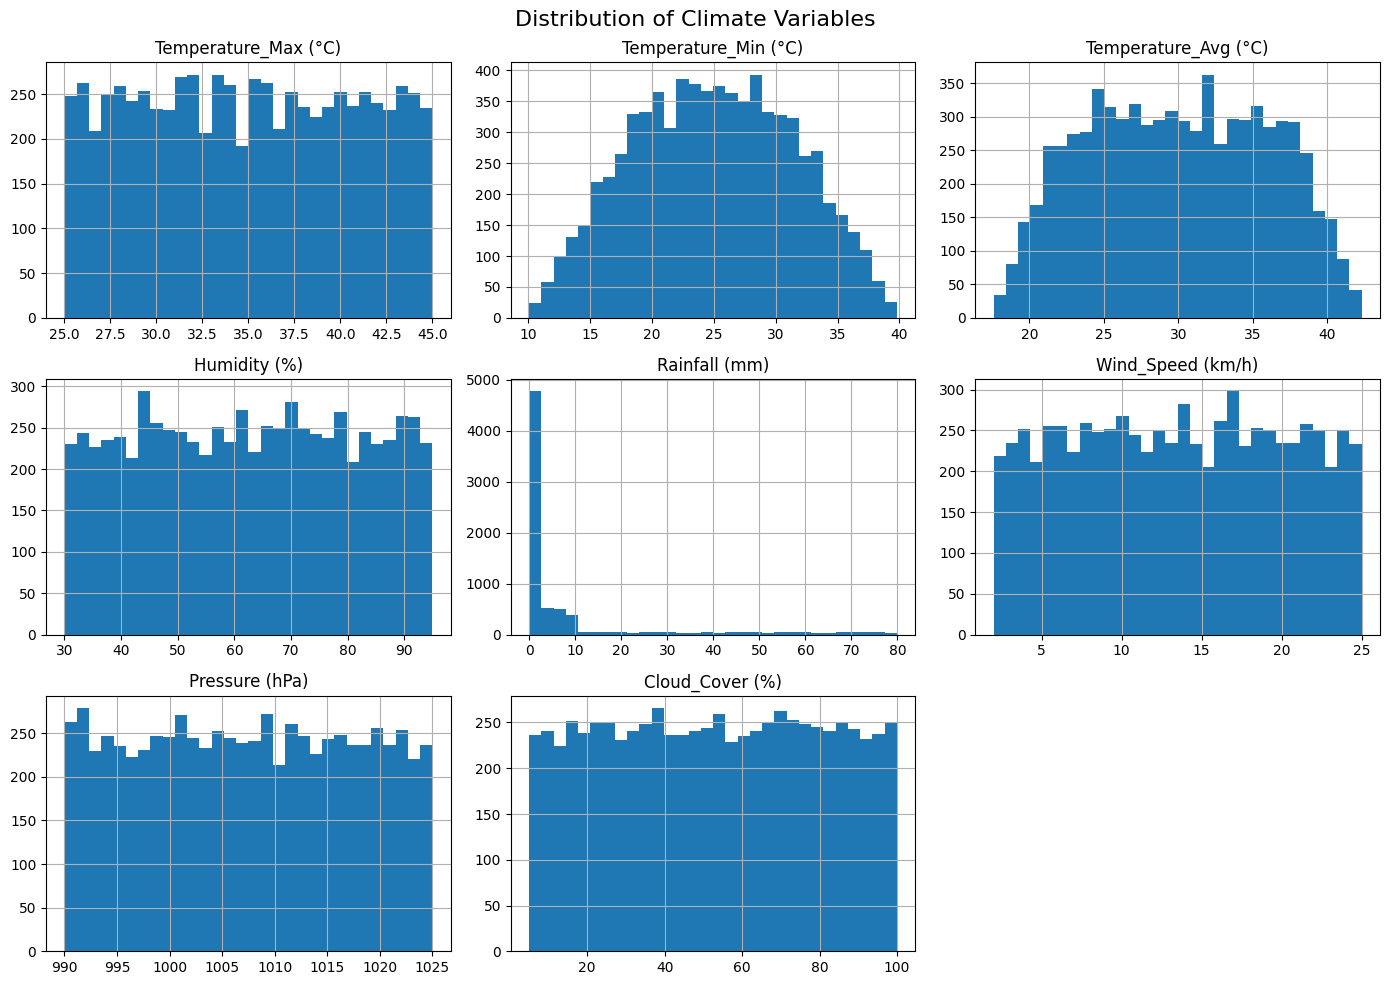

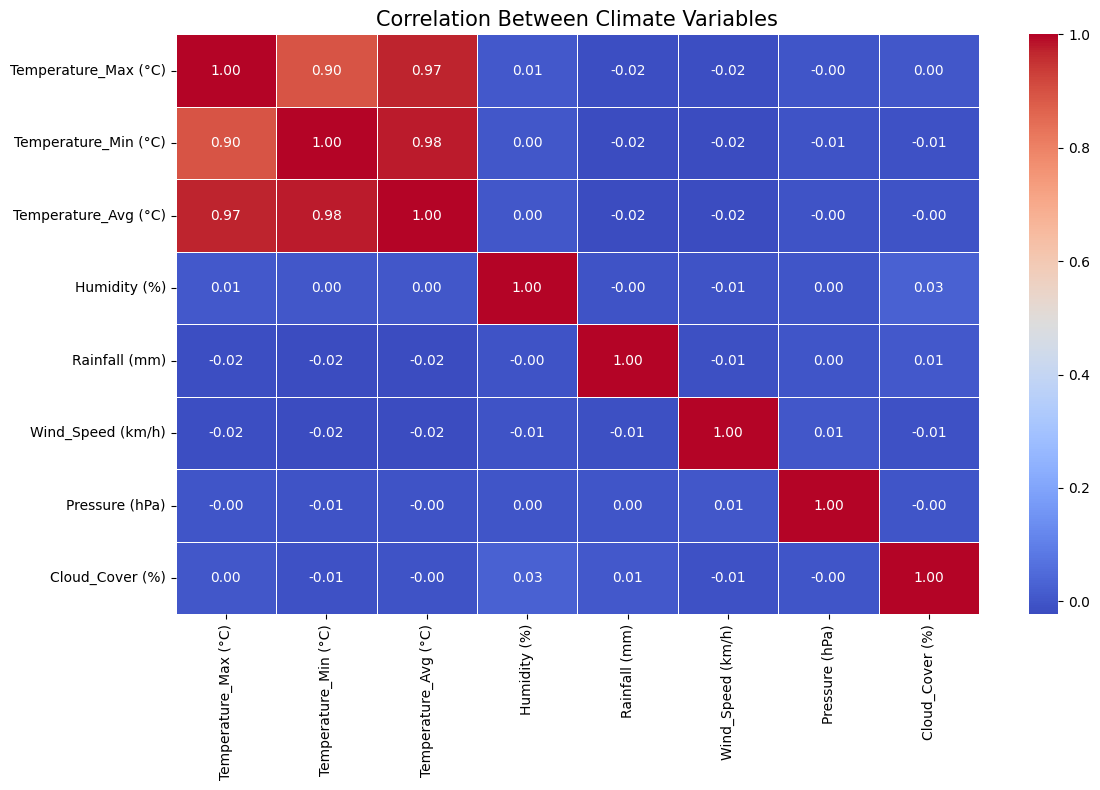


PCA Explained Variance:
PC1: 0.362
PC2: 0.1293
Total: 0.4913


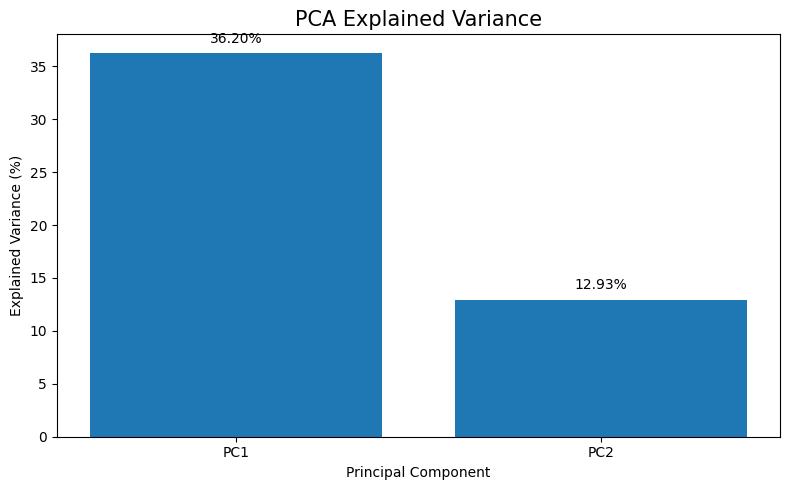

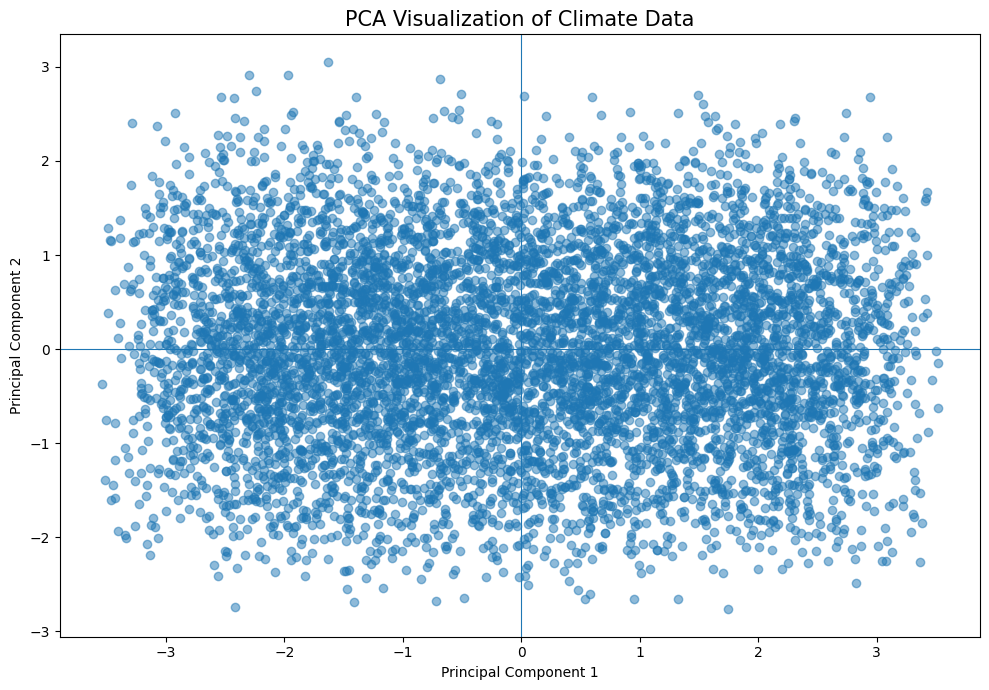

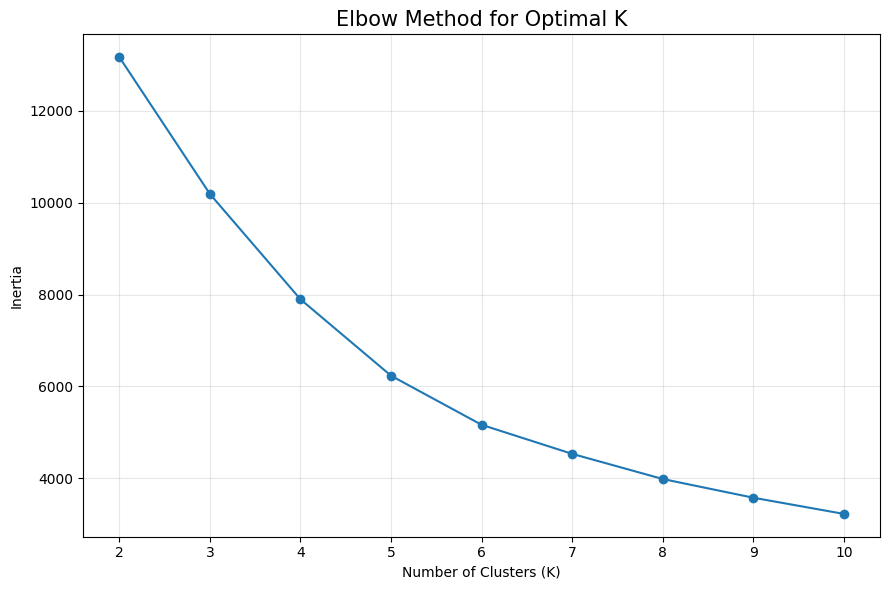

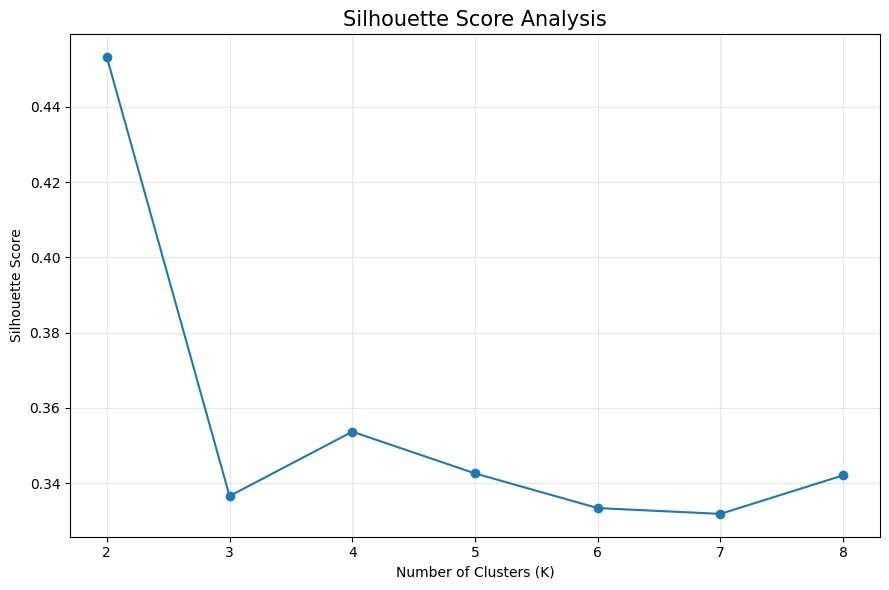


Silhouette Scores:
K = 2 → 0.4532
K = 3 → 0.3366
K = 4 → 0.3537
K = 5 → 0.3426
K = 6 → 0.3334
K = 7 → 0.3318
K = 8 → 0.3421

Best K according to Silhouette Score: 2
Best Silhouette Score: 0.4532


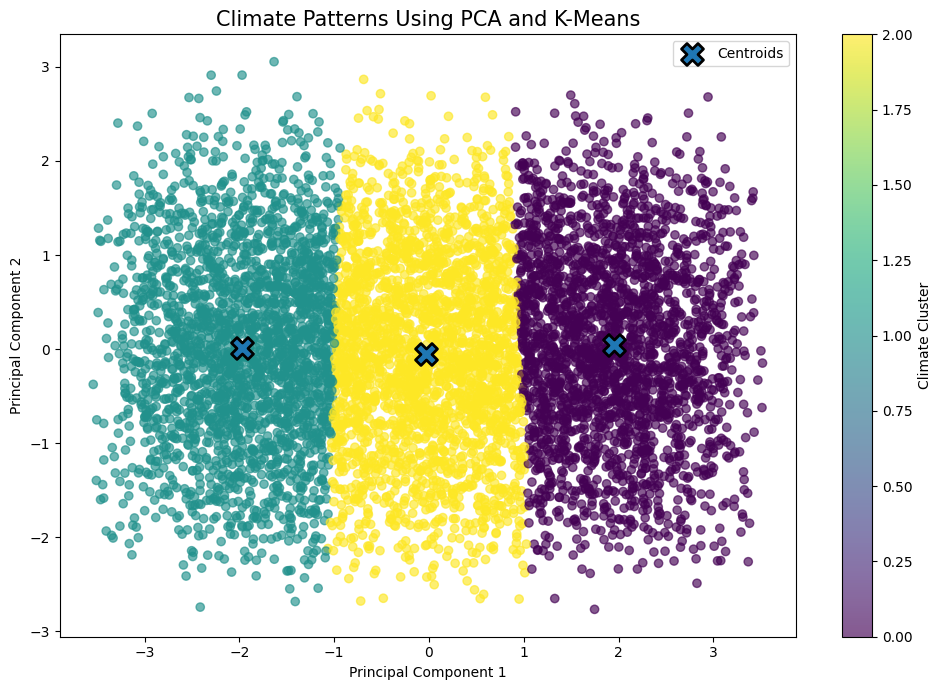

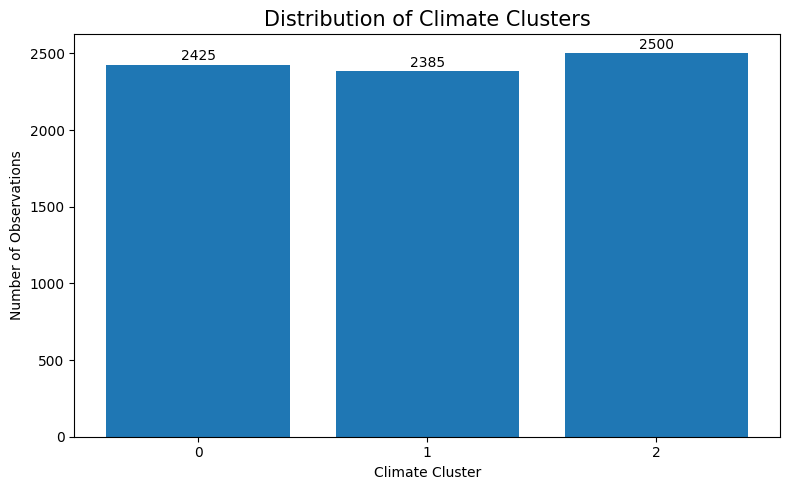


Average Climate Characteristics:


,Temperature_Max (°C),Temperature_Min (°C),Temperature_Avg (°C),Humidity (%),Rainfall (mm),Wind_Speed (km/h),Pressure (hPa),Cloud_Cover (%)
Cluster,,,,,,,,
0,41.53,32.15,36.84,63.19,7.81,13.17,1007.30,53.27
1,28.40,17.77,23.09,62.83,8.90,13.65,1007.47,52.88
2,34.83,24.98,29.90,61.96,8.00,13.75,1007.31,51.77


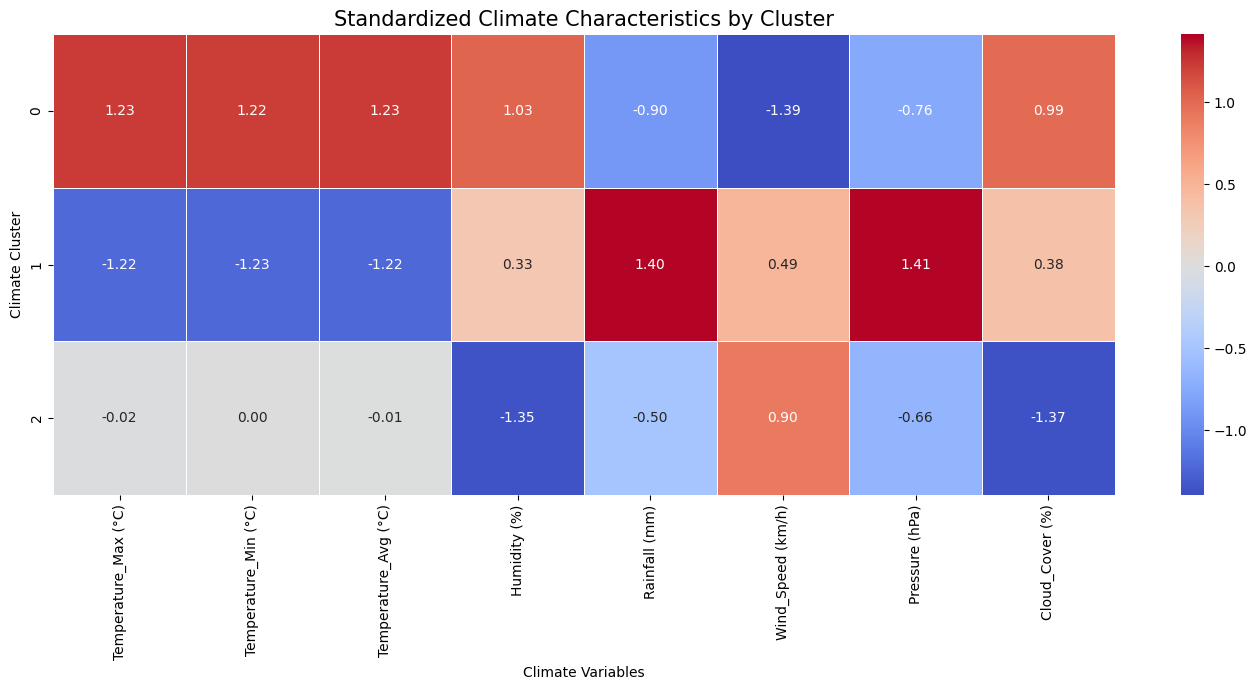

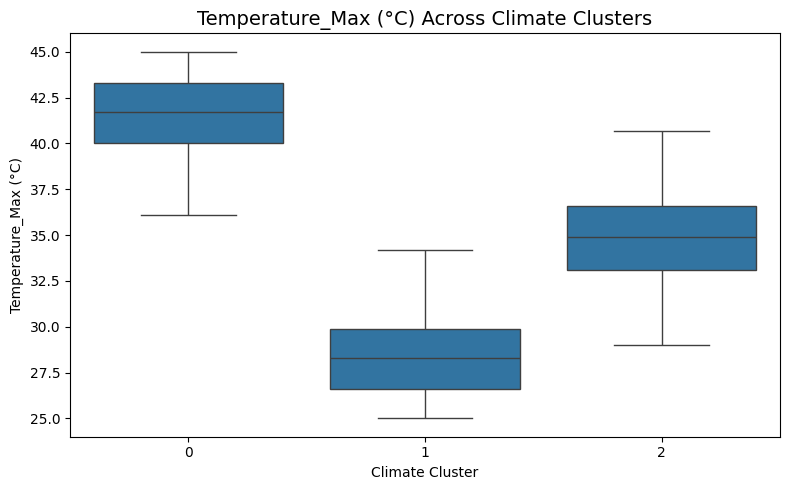

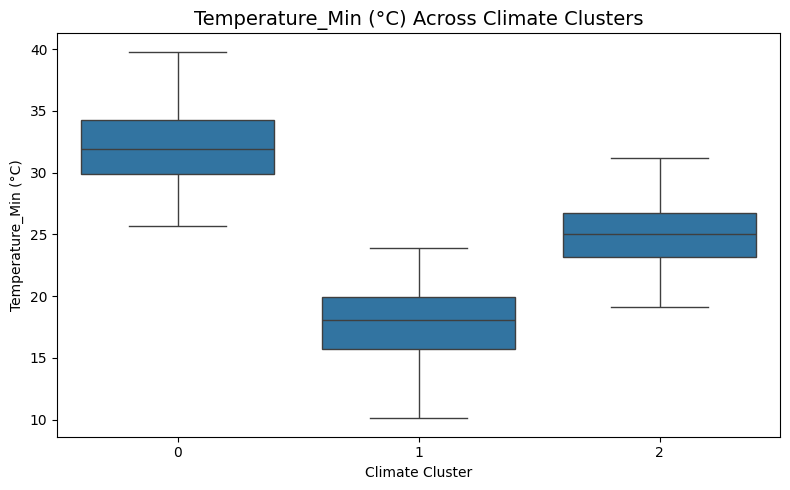

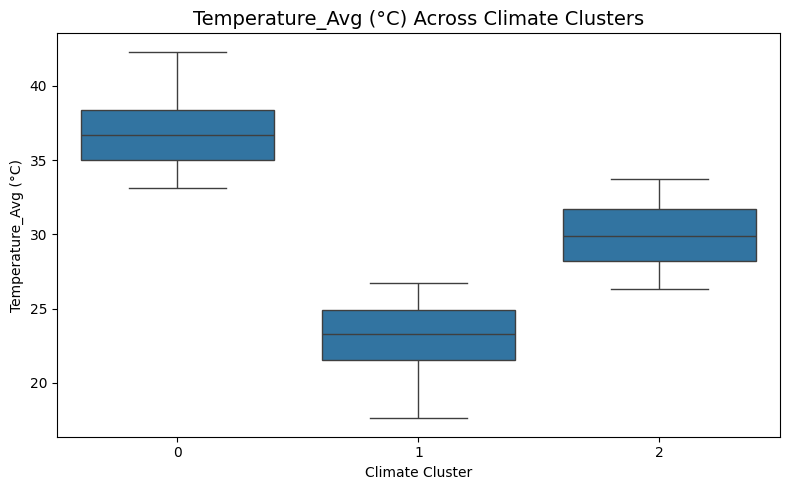

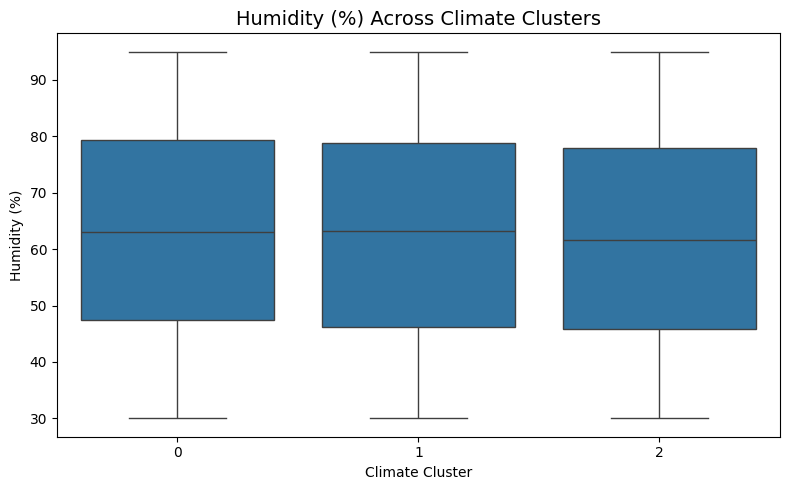

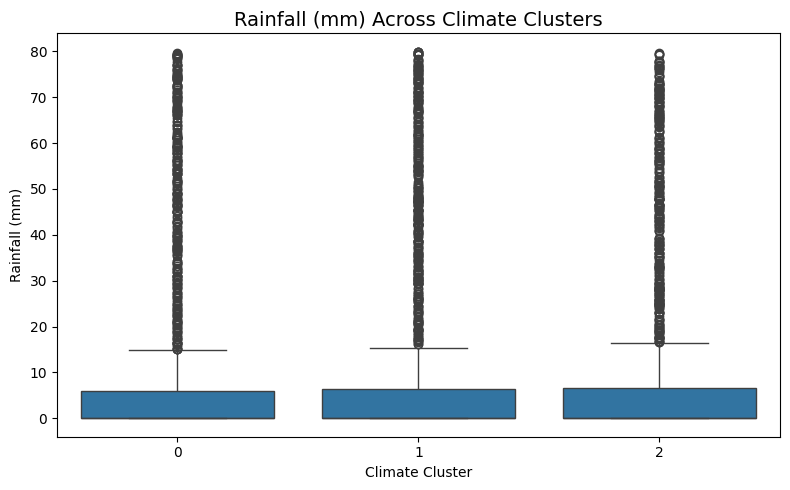

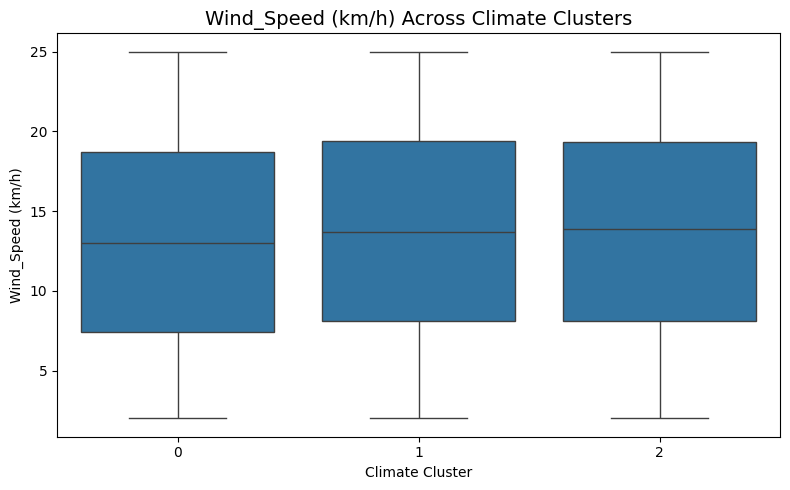

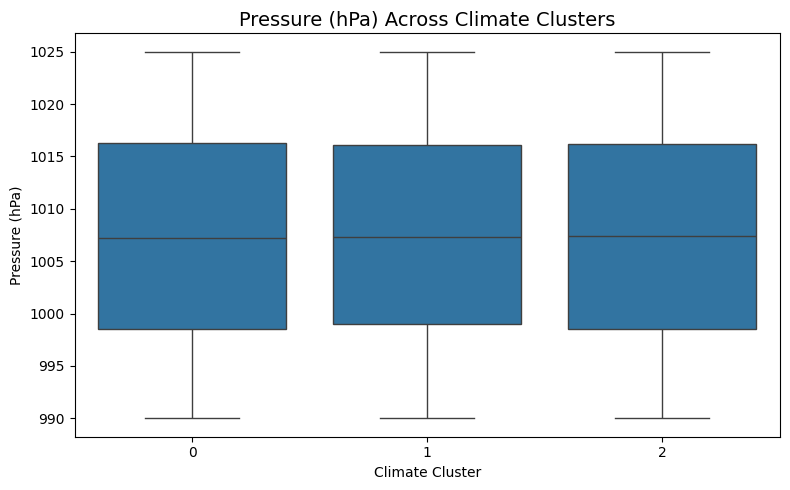

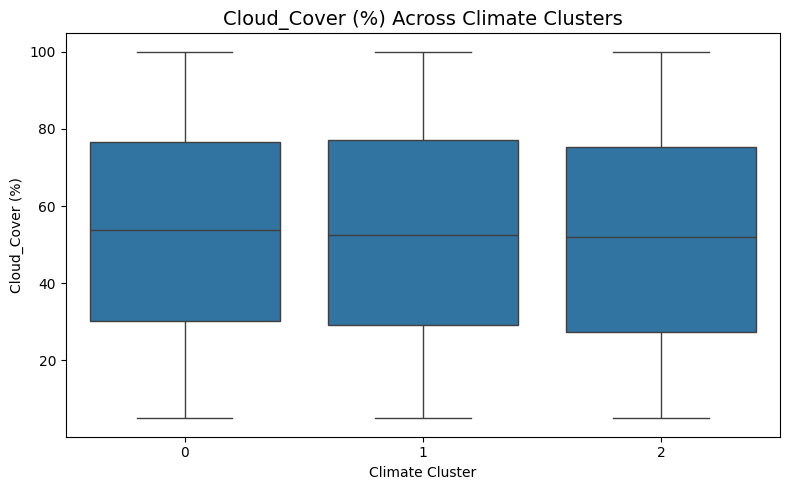


FINAL PROJECT RESULTS
Dataset Records: 7310
Features Used: 8
PCA Explained Variance: 49.13 %
Selected K: 3
Final Silhouette Score: 0.3366

Cluster Distribution:
Cluster
0    2425
1    2385
2    2500
Name: count, dtype: int64

Cluster Characteristics:


,Temperature_Max (°C),Temperature_Min (°C),Temperature_Avg (°C),Humidity (%),Rainfall (mm),Wind_Speed (km/h),Pressure (hPa),Cloud_Cover (%)
Cluster,,,,,,,,
0,41.53,32.15,36.84,63.19,7.81,13.17,1007.30,53.27
1,28.40,17.77,23.09,62.83,8.90,13.65,1007.47,52.88
2,34.83,24.98,29.90,61.96,8.00,13.75,1007.31,51.77


In [ ]:
# ============================================================
# CLIMATE PATTERN ANALYSIS USING K-MEANS + PCA
# COMPLETE VISUALIZATION CODE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ------------------------------------------------------------
# 1. FEATURES
# ------------------------------------------------------------

features = [
    "Temperature_Max (°C)",
    "Temperature_Min (°C)",
    "Temperature_Avg (°C)",
    "Humidity (%)",
    "Rainfall (mm)",
    "Wind_Speed (km/h)",
    "Pressure (hPa)",
    "Cloud_Cover (%)"
]

X = df[features]

print("Number of records:", len(X))
print("Number of features:", len(features))


# ============================================================
# GRAPH 1 — DISTRIBUTION OF CLIMATE VARIABLES
# ============================================================

X.hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle(
    "Distribution of Climate Variables",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 2 — CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(12, 8))

sns.heatmap(
    X.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    "Correlation Between Climate Variables",
    fontsize=15
)

plt.tight_layout()
plt.show()


# ============================================================
# STANDARDIZATION
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# ============================================================
# PCA
# ============================================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

print("\nPCA Explained Variance:")
print("PC1:", round(explained_variance[0], 4))
print("PC2:", round(explained_variance[1], 4))
print(
    "Total:",
    round(explained_variance.sum(), 4)
)


# ============================================================
# GRAPH 3 — PCA EXPLAINED VARIANCE
# ============================================================

plt.figure(figsize=(8, 5))

components = [
    "PC1",
    "PC2"
]

plt.bar(
    components,
    explained_variance * 100
)

plt.ylabel("Explained Variance (%)")
plt.xlabel("Principal Component")

plt.title(
    "PCA Explained Variance",
    fontsize=15
)

for i, value in enumerate(explained_variance * 100):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 4 — PCA 2D VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "PCA Visualization of Climate Data",
    fontsize=15
)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 5 — ELBOW METHOD
# ============================================================

inertia = []

K_values = range(2, 11)

for k in K_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_pca)

    inertia.append(model.inertia_)


plt.figure(figsize=(9, 6))

plt.plot(
    list(K_values),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.title(
    "Elbow Method for Optimal K",
    fontsize=15
)

plt.xticks(list(K_values))

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 6 — SILHOUETTE SCORE
# ============================================================

silhouette_scores = {}

for k in range(2, 9):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_pca)

    score = silhouette_score(
        X_pca,
        labels
    )

    silhouette_scores[k] = score


plt.figure(figsize=(9, 6))

plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.title(
    "Silhouette Score Analysis",
    fontsize=15
)

plt.xticks(
    list(silhouette_scores.keys())
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# PRINT SILHOUETTE RESULTS
# ============================================================

print("\nSilhouette Scores:")

for k, score in silhouette_scores.items():

    print(
        f"K = {k} → {score:.4f}"
    )


best_k = max(
    silhouette_scores,
    key=silhouette_scores.get
)

print(
    "\nBest K according to Silhouette Score:",
    best_k
)

print(
    "Best Silhouette Score:",
    round(
        silhouette_scores[best_k],
        4
    )
)


# ============================================================
# K-MEANS
# ============================================================

# IMPORTANT:
# Change this after looking at the Elbow + Silhouette results.

optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_pca)

df["Cluster"] = clusters


# ============================================================
# GRAPH 7 — PCA + K-MEANS CLUSTERS
# ============================================================

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="viridis",
    alpha=0.65
)

# Plot centroids
centroids = kmeans.cluster_centers_

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=250,
    edgecolor="black",
    linewidth=2,
    label="Centroids"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "Climate Patterns Using PCA and K-Means",
    fontsize=15
)

plt.legend()

plt.colorbar(
    scatter,
    label="Climate Cluster"
)

plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 8 — CLUSTER DISTRIBUTION
# ============================================================

cluster_counts = (
    df["Cluster"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.xlabel("Climate Cluster")
plt.ylabel("Number of Observations")

plt.title(
    "Distribution of Climate Clusters",
    fontsize=15
)

for i, value in enumerate(cluster_counts.values):

    plt.text(
        i,
        value + 30,
        str(value),
        ha="center"
    )

plt.tight_layout()
plt.show()


# ============================================================
# CLUSTER ANALYSIS
# ============================================================

cluster_analysis = (
    df.groupby("Cluster")[features]
    .mean()
)

print("\nAverage Climate Characteristics:")
display(
    cluster_analysis.round(2)
)


# ============================================================
# GRAPH 9 — STANDARDIZED CLUSTER CHARACTERISTICS
# ============================================================

cluster_scaled = pd.DataFrame(
    StandardScaler().fit_transform(
        cluster_analysis
    ),
    index=cluster_analysis.index,
    columns=cluster_analysis.columns
)

plt.figure(figsize=(14, 7))

sns.heatmap(
    cluster_scaled,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Standardized Climate Characteristics by Cluster",
    fontsize=15
)

plt.xlabel("Climate Variables")
plt.ylabel("Climate Cluster")

plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 10 — CLIMATE VARIABLES BY CLUSTER
# ============================================================

# Plot each variable separately to avoid pressure/AQI dominating
# the visualization.

for feature in features:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="Cluster",
        y=feature
    )

    plt.title(
        f"{feature} Across Climate Clusters",
        fontsize=14
    )

    plt.xlabel("Climate Cluster")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()


# ============================================================
# FINAL RESULTS
# ============================================================

print("\n======================================")
print("FINAL PROJECT RESULTS")
print("======================================")

print(
    "Dataset Records:",
    len(df)
)

print(
    "Features Used:",
    len(features)
)

print(
    "PCA Explained Variance:",
    round(
        explained_variance.sum() * 100,
        2
    ),
    "%"
)

print(
    "Selected K:",
    optimal_k
)

final_silhouette = silhouette_score(
    X_pca,
    clusters
)

print(
    "Final Silhouette Score:",
    round(
        final_silhouette,
        4
    )
)

print("\nCluster Distribution:")
print(cluster_counts)

print("\nCluster Characteristics:")
display(
    cluster_analysis.round(2)
)